<h1 style="color: #CEDDF4;">DEPI Round 4, MS Data Engineer and AI Track</h1>
<h2 style="color: #CEDDF4;" >Final Project: Gold and Oil Prediction System</h2>
<h3 style="color: #CEDDF4;" > Part (2): Python Code for Machine Learning and Modeling</h3>

<h4 style="color: #CEDDF4;" >1. Import Libraries</h4>

In [1]:
import pandas as pd
import numpy as np
import math
from pathlib import Path
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,precision_score
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
import xgboost as xgb
from xgboost import XGBClassifier,XGBRegressor
import joblib
from sklearn.preprocessing import StandardScaler
from functools import reduce
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier

In [2]:
base_dir = Path.cwd()
#raw data path to contain all raw files gathered either manually, web scraping or APIs
raw_data_dir=base_dir/'raw data'
#cleaned data path, will be separated into two main folders which are: market data (contains the data with daily logs) and macroeconomic data
##cleaned market data
cleaned_market_data_dir=base_dir/'cleaned data'/'market_data'
##cleaned macroeconomic data
cleaned_macro_data_dir=base_dir/'cleaned data'/'macroeconomic_data'
##ai modeling data
ai_data_dir=base_dir/'ai model'

<h4 style="color: #CEDDF4;" >1. Data Loading and Processing</h4>

In [3]:
def make_tag(filename):
    tag = filename
    tag = tag.replace('global_', '').replace('usa_', '').replace('egy_', '')
    tag = tag.replace('_prices', '').replace('_price', '').replace('_index', '').replace('_rate', '')
    return tag

In [ ]:
#the below function is made to call all the date within specific folder (market / macro) and make final cleaning and sorting methods on it to be using in our master table
def loading(filename, tag, dir):
    df = pd.read_csv(dir / f"{filename}.csv")
    df = df.drop(columns=['id', 'region', 'ticker'], errors='ignore')
    df['date'] = pd.to_datetime(df['date'], dayfirst=True, format='mixed', errors='coerce')
    df = df.rename(columns={c: f"{tag}_{c}" for c in df.columns if c != 'date'})
    df = df.drop_duplicates(subset='date')
    df = df.set_index('date')
    full_dates = pd.date_range(start='2016-01-01', end='2026-03-29', freq='D')
    df = df.reindex(full_dates)
    first_valid = df.first_valid_index()
    if first_valid is not None:
        df.loc[:first_valid] = df.loc[:first_valid].bfill()
    df = df.ffill()
    df = df.reset_index().rename(columns={'index': 'date'})
    return df

In [5]:
#the below is for loop to iterate over all files within cleaned market data 
all_market_df=[]
for filepath in cleaned_market_data_dir.glob("*.csv"):
    raw_file_name = filepath.stem
    tag = make_tag(raw_file_name)
    new_df = loading(raw_file_name, tag, cleaned_market_data_dir)
    all_market_df.append(new_df)

In [ ]:
#the below is a minor tweak to egy_cpi file in macroeconomic data folder which is obtained via data_cleaning.ipynb section 2.1
egy_cpi=pd.read_csv(cleaned_macro_data_dir/'egy_cpi.csv')
egy_cpi=egy_cpi.rename(columns={'year':'date'})
egy_cpi.to_csv(cleaned_macro_data_dir/'egy_cpi.csv')

In [6]:
#the below is for loop to iterate over all files within cleaned macroeconomic data data 
all_macro_df=[]
for filepath in cleaned_macro_data_dir.glob("*.csv"):
    raw_file_name = filepath.stem
    tag = make_tag(raw_file_name)
    new_df = loading(raw_file_name, tag, cleaned_macro_data_dir)
    all_macro_df.append(new_df)

In [7]:
#get all dataframes from previous steps in one dataframe as reduce function takes only one argument
all_df = all_macro_df + all_market_df
#create the master table and make data column the primary key for merging process
master_table = reduce(lambda left, right: pd.merge(left, right, on='date', how='outer'), all_df)
master_table = master_table.dropna(axis=1, how='all')

In [8]:
#saving the master table into a csv file to be used in the modeling
master_table.to_csv(ai_data_dir/'master_table.csv')

In [9]:
df=pd.read_csv(ai_data_dir/'master_table.csv')

In [10]:
df = df.bfill().ffill()

In [11]:
df.to_csv(ai_data_dir/'new_master_table.csv')

In [12]:
#only when VS Code crashes
df=pd.read_csv(ai_data_dir/'new_master_table.csv')

In [13]:
df.shape

(3741, 51)

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3741 entries, 0 to 3740
Data columns (total 51 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Unnamed: 0.1                 3741 non-null   int64  
 1   Unnamed: 0                   3741 non-null   int64  
 2   date                         3741 non-null   str    
 3   china_gdp_value_usd          3741 non-null   float64
 4   china_ir_value               3741 non-null   float64
 5   euro_inflation_value         3741 non-null   float64
 6   euro_interest_value          3741 non-null   float64
 7   japan_10yy_value             3741 non-null   float64
 8   japan_2yy_value              3741 non-null   float64
 9   japan_cpi_value              3741 non-null   float64
 10  japan_gdp_value              3741 non-null   float64
 11  japan_ir_value               3741 non-null   float64
 12  norway_10yy_value            3741 non-null   float64
 13  norway_2yy_value             

In [15]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df = df.drop(columns=['gpr_event'], errors='ignore')
data = df[df['date'] <= '2026-02-28'].copy()
march_data = df[df['date'] >= '2026-03-01'].copy()

In [16]:
describtion_df = data.describe()

In [17]:
describtion_df.to_csv(ai_data_dir/'stats.csv')

<Axes: >

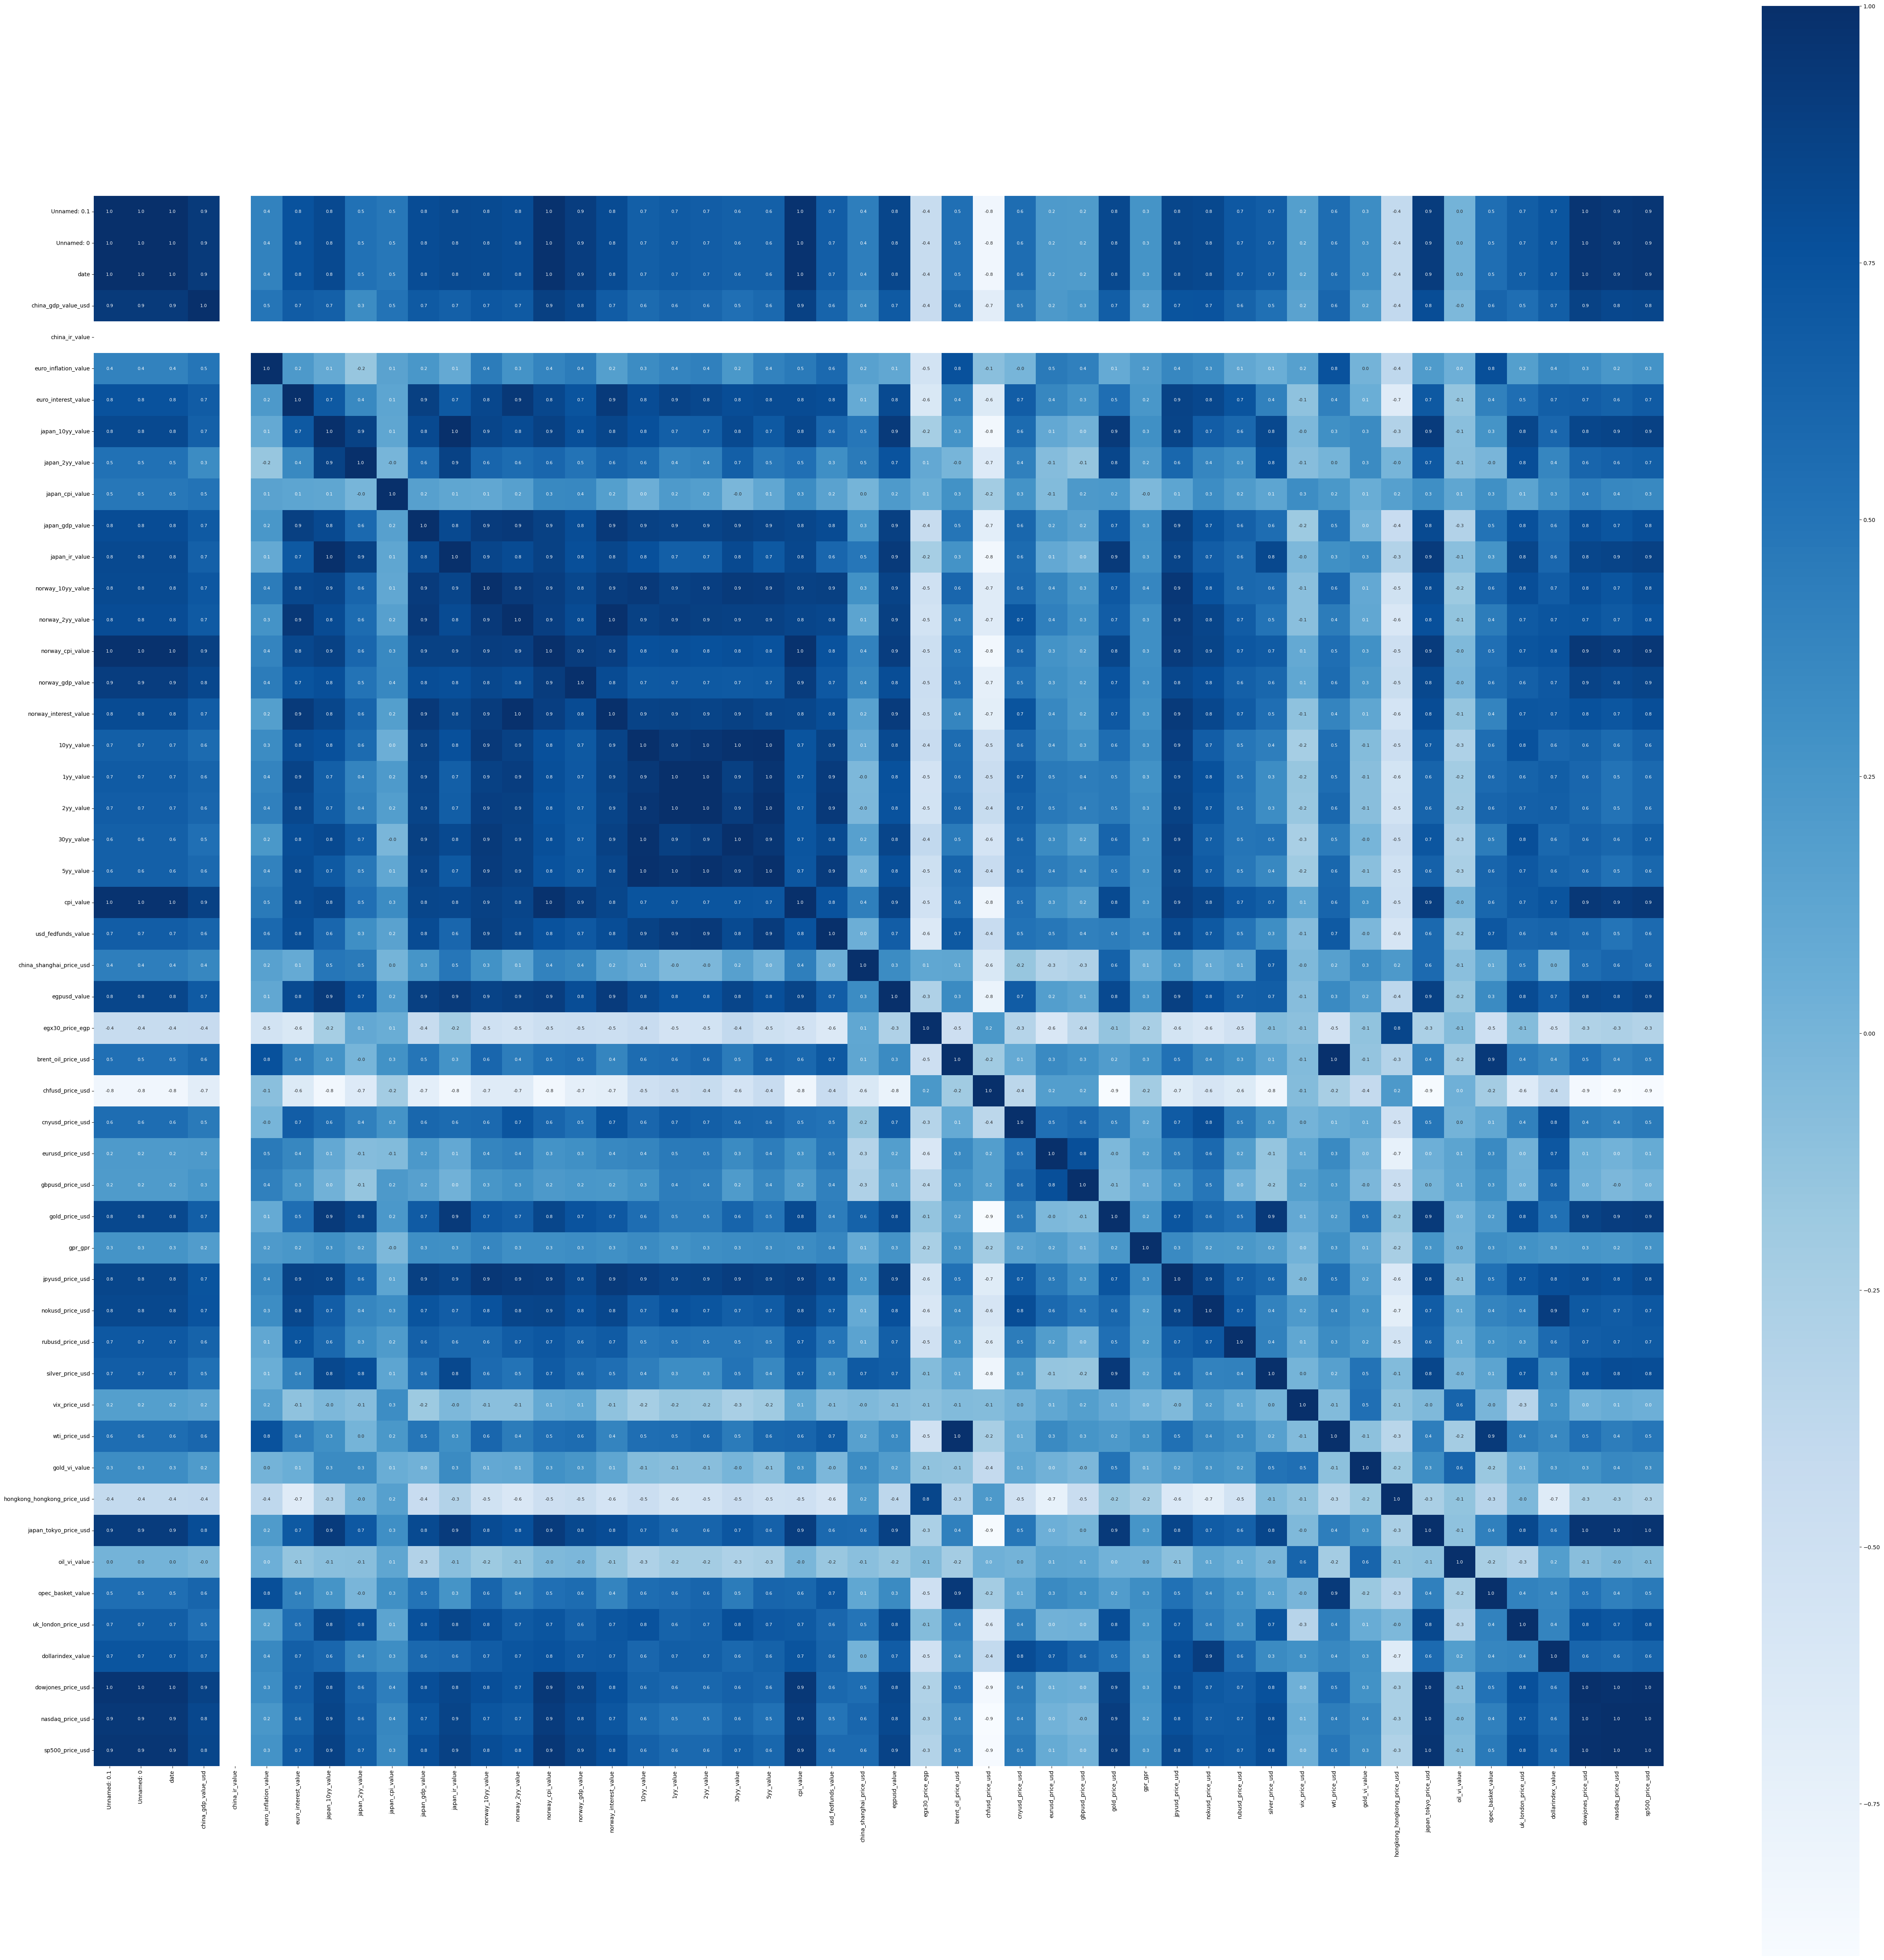

In [18]:
#finding correlations
correlation = data.corr()

#heat map to understand correlation
plt.figure(figsize=(64,64))
sns.heatmap(correlation,cbar=True,square=True,fmt='.1f',annot=True,annot_kws={'size':8},cmap='Blues')

In [19]:
#correlation values for gold prices
print(correlation['gold_price_usd'])

Unnamed: 0.1                   0.824153
Unnamed: 0                     0.824153
date                           0.824153
china_gdp_value_usd            0.662728
china_ir_value                      NaN
euro_inflation_value           0.086555
euro_interest_value            0.546177
japan_10yy_value               0.923419
japan_2yy_value                0.841762
japan_cpi_value                0.233976
japan_gdp_value                0.682472
japan_ir_value                 0.923419
norway_10yy_value              0.703464
norway_2yy_value               0.667461
norway_cpi_value               0.839486
norway_gdp_value               0.741984
norway_interest_value          0.709324
10yy_value                     0.551416
1yy_value                      0.461780
2yy_value                      0.460953
30yy_value                     0.620129
5yy_value                      0.489341
cpi_value                      0.807712
usd_fedfunds_value             0.439211
china_shanghai_price_usd       0.631420


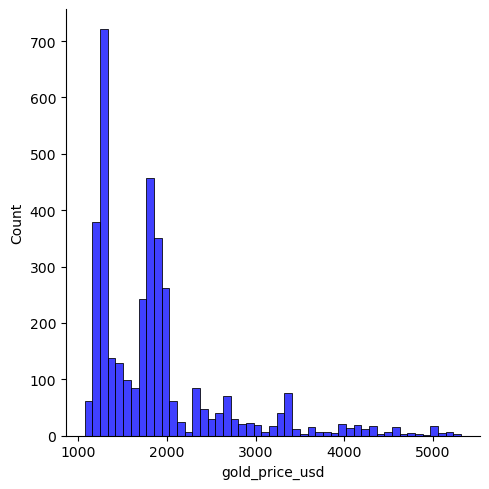

In [20]:
#check the distribution of gold price
sns.displot(data['gold_price_usd'],color='blue')

Splitting data (features and target)

In [21]:
X = data.drop(['date','gold_price_usd'],axis=1)
Y=data['gold_price_usd']

Train / Test Data

In [22]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size= 0.2,random_state=2)

model train

In [23]:
regressor=xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)

In [24]:
#training
regressor.fit(X_train,Y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [25]:
#model eval
test_data_preds = regressor.predict(X_test)

In [26]:
#squared error
error_score = metrics.r2_score(Y_test,test_data_preds)
print("R Squared Error :",error_score)

R Squared Error : 0.9986716763877331


In [29]:
X_march = march_data.drop(['date', 'gold_price_usd'], axis=1)
march_preds = regressor.predict(X_march)
march_results = march_data.copy()
march_results['gold_predicted'] = march_preds


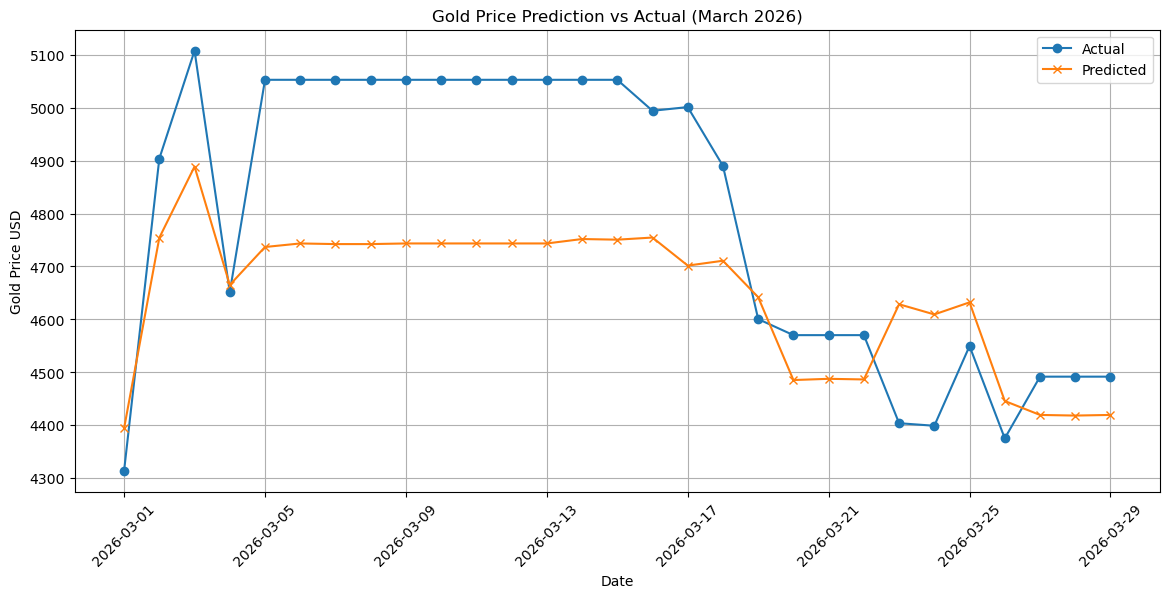

In [30]:
#comparing
plt.figure(figsize=(14,6))
plt.plot(march_results['date'], march_results['gold_price_usd'], label='Actual', marker='o')
plt.plot(march_results['date'], march_results['gold_predicted'], label='Predicted', marker='x')
plt.title('Gold Price Prediction vs Actual (March 2026)')
plt.xlabel('Date')
plt.ylabel('Gold Price USD')
plt.legend()
plt.xticks(rotation=45)
plt.grid()
plt.show()

0.5840479113440094


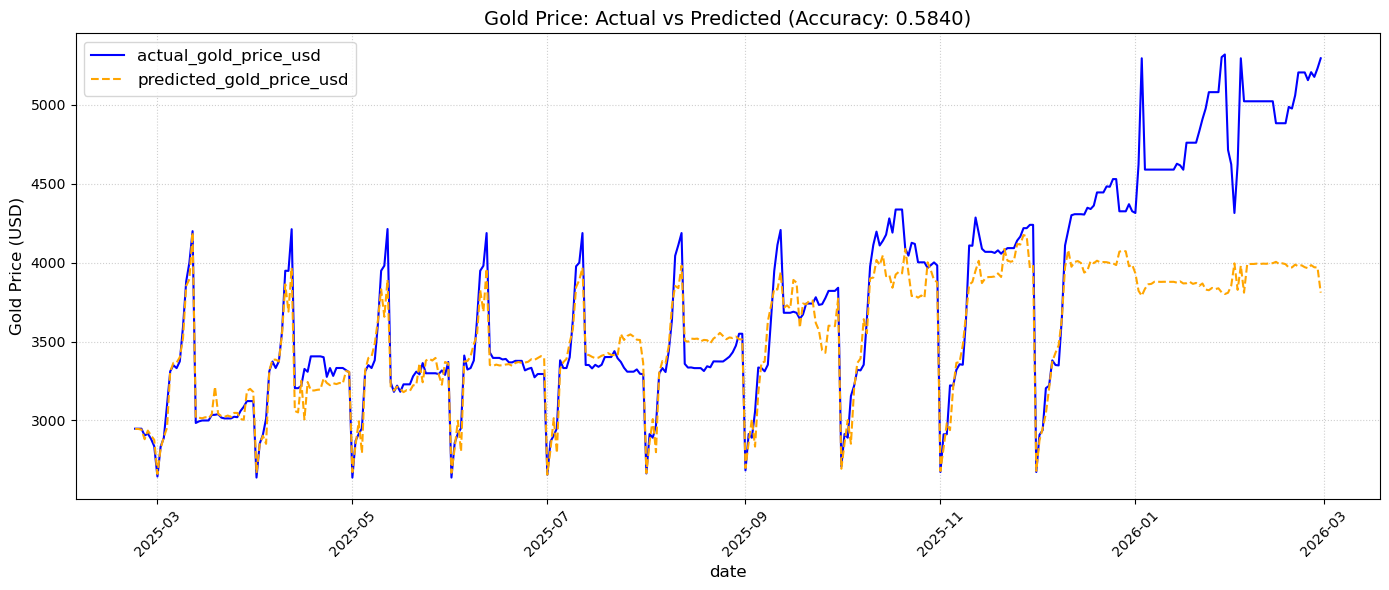

In [ ]:
##my work, accuracy after manual cleaning is .7047
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df = df.drop(columns=['gpr_event'], errors='ignore')
df = df.sort_values('date').reset_index(drop=True)

data = df[df['date'] <= '2026-02-28'].copy()
march_data = df[df['date'] >= '2026-03-01'].copy()

model = xgb.XGBRegressor(
    n_estimators=600,      
    learning_rate=0.025,
    max_depth=5,
    subsample=0.85,
    colsample_bytree=0.85,
    random_state=42,
    eval_metric='rmse'
)

train=data.iloc[:int(.9*len(data)),:]
test_data=data.iloc[int(.9*len(data)):,:]
target = 'gold_price_usd'
predictors = [col for col in data.columns if col not in ['date', target]]


model.fit(train[predictors],train[target])
preds=model.predict(test_data[predictors])


results = pd.DataFrame({
    'date': test_data['date'],
    'actual_gold_price_usd': test_data[target],
    'predicted_gold_price_usd': preds
})

accuracy=model.score(test_data[predictors], test_data[target])
print(accuracy)

#plotting the results
plt.figure(figsize=(14, 6))
plt.plot(results['date'], results['actual_gold_price_usd'], label='actual_gold_price_usd', color='blue')
plt.plot(results['date'], results['predicted_gold_price_usd'], label='predicted_gold_price_usd', color='orange', linestyle='--')

# Formatting the plot
plt.title(f'Gold Price: Actual vs Predicted (Accuracy: {accuracy:.4f})', fontsize=14)
plt.xlabel('date', fontsize=12)
plt.ylabel('Gold Price (USD)', fontsize=12)
plt.legend(fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

# Save the plot as an image and show it
plt.savefig('test_predictions_plot.png', dpi=300)
plt.show()

Features used: ['Unnamed: 0', 'china_cpi_value', 'china_gdp_value_usd', 'china_ir_value', 'euro_gdp_value', 'euro_inflation_value', 'euro_interest_value', 'japan_10yy_value', 'japan_2yy_value', 'japan_cpi_value', 'japan_gdp_value', 'japan_ir_value', 'norway_10yy_value', 'norway_2yy_value', 'norway_cpi_value', 'norway_gdp_value', 'norway_interest_value', '10yy_value', '1yy_value', '2yy_value', '30yy_value', '5yy_value', 'cpi_value_y', 'nominal_gdp_value', 'real_gdp_value', 'usd_fedfunds_value', 'china_shanghai_price_usd', 'egpusd_value', 'egx30_price_egp', 'ai_gpr_Unnamed: 0', 'ai_gpr_gpr_ai', 'ai_gpr_gpr_aer', 'ai_gpr_gpr_oil', 'ai_gpr_gpr_nonoil', 'brent_oil_price_usd', 'chfusd_price_usd', 'cnyusd_price_usd', 'copper_price_usd', 'eurusd_price_usd', 'gbpusd_price_usd', 'gpr_gpr', 'jpyusd_price_usd', 'nokusd_price_usd', 'rubusd_price_usd', 'silver_price_usd', 'vix_price_usd', 'wti_price_usd', 'gold_vi_value', 'hongkong_hongkong_price_usd', 'japan_tokyo_price_usd', 'oil_vi_value', 'opec_

C:\Users\HMSY\AppData\Local\Temp\ipykernel_21984\3457694603.py:147: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(results.round(2))


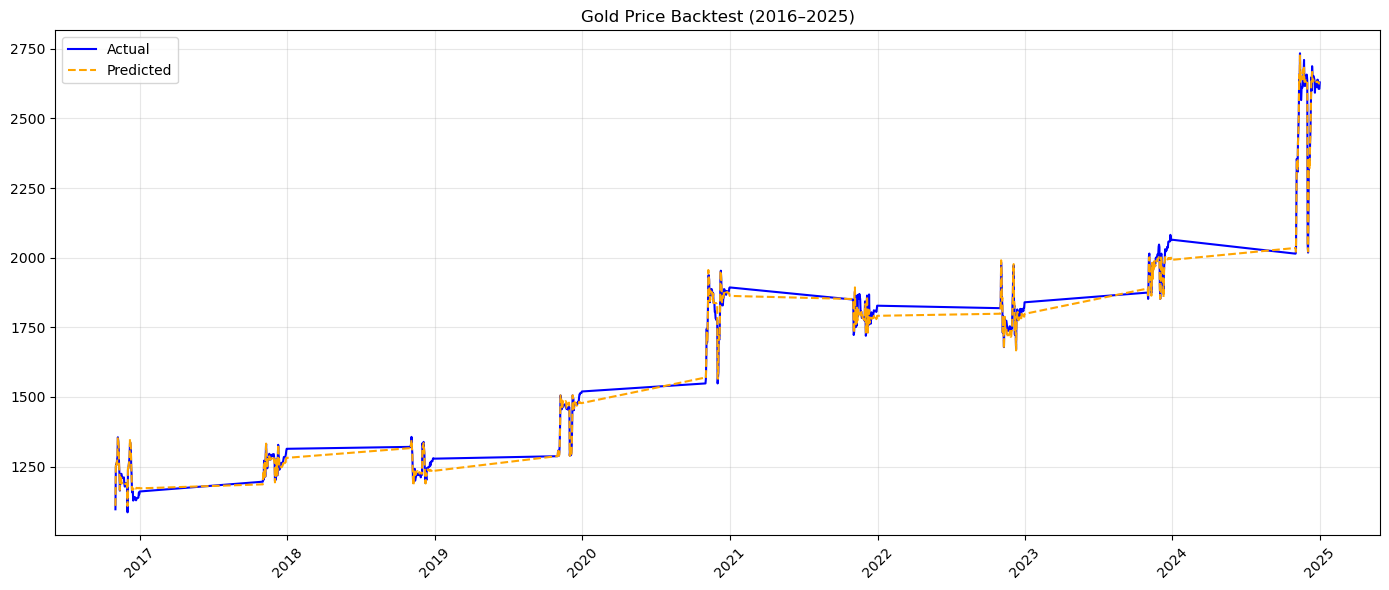

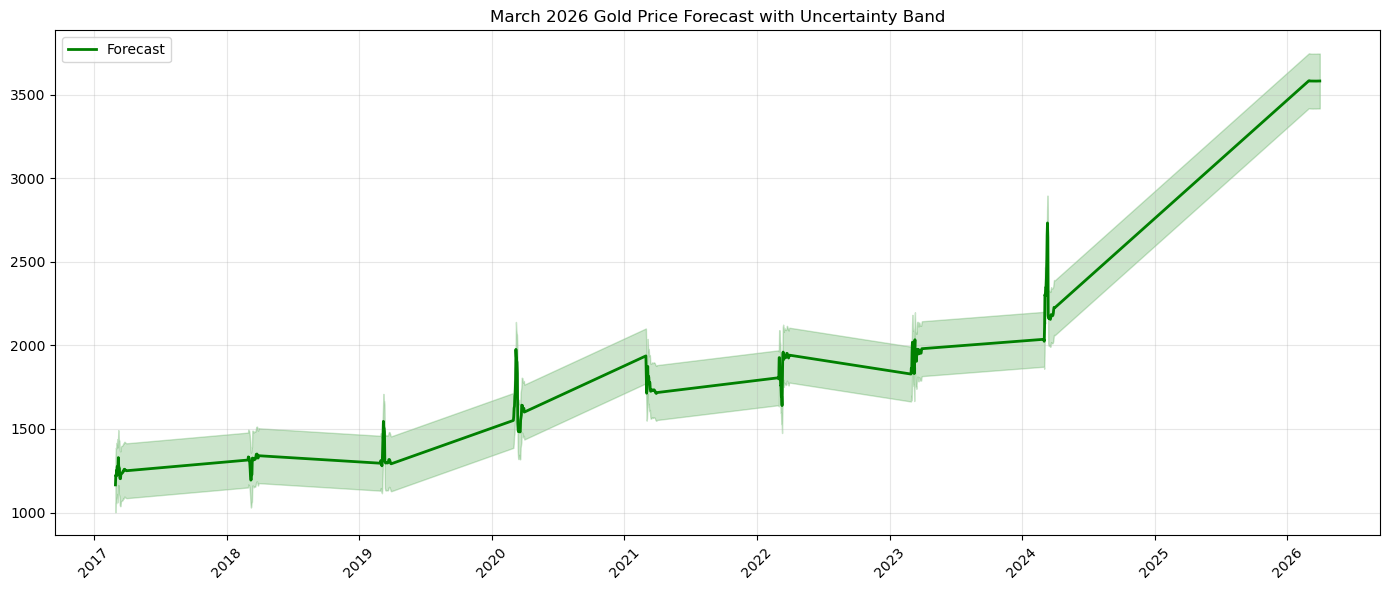

Forecast saved to march_2026_gold_forecast.csv


In [ ]:

df['date'] = pd.to_datetime(df['date'], dayfirst=True)


df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df = df.drop(columns=['gpr_event'], errors='ignore')
df = df.sort_values('date').reset_index(drop=True)

#engineering data proposed by claude

def create_features(data):
    data = data.copy()
    data['year'] = data['date'].dt.year
    data['month'] = data['date'].dt.month
    data['day'] = data['date'].dt.day
    
    # Lags
    data['lag_1'] = data['gold_price_usd'].shift(1)
    data['lag_2'] = data['gold_price_usd'].shift(2)
    data['lag_7'] = data['gold_price_usd'].shift(7)
    
    # Rolling stats
    data['roll_mean_7'] = data['gold_price_usd'].rolling(window=7).mean()
    data['roll_mean_30'] = data['gold_price_usd'].rolling(window=30).mean()
    data['roll_std_7'] = data['gold_price_usd'].rolling(window=7).std()
    
    return data

df = create_features(df)
df = df.dropna().reset_index(drop=True)

target = 'gold_price_usd'
exclude_cols = ['date', target]
predictors = [c for c in df.columns if c not in exclude_cols]

print(f"Features used: {predictors}")
print(f"Final dataset shape: {df.shape}")

# =========================
# 3. WALK-FORWARD BACKTEST (2016–2025)
# =========================
backtest_results = []

for year in range(2016, 2026):
    year_data = df[df['year'] == year].copy()
    if len(year_data) < 25:
        continue
        
    train_part = year_data[year_data['month'] <= 10]
    test_part = year_data[year_data['month'] > 10]
    
    if len(train_part) < 20 or len(test_part) < 5:
        continue
    
    model = xgb.XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='rmse'
    )
    
    model.fit(train_part[predictors], train_part[target])
    preds = model.predict(test_part[predictors])
    
    backtest_results.append(pd.DataFrame({
        'date': test_part['date'],
        'actual': test_part[target],
        'predicted': preds
    }))

backtest = pd.concat(backtest_results, ignore_index=True) if backtest_results else pd.DataFrame()

if not backtest.empty:
    r2_backtest = r2_score(backtest['actual'], backtest['predicted'])
    print(f"Backtest R² (2016-2025 Nov/Dec): {r2_backtest:.4f}")

# =========================
# 4. FINAL MODEL (up to Feb 2026)
# =========================
train_final = df[df['date'] <= '2026-02-28'].copy()

final_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.85,
    colsample_bytree=0.85,
    random_state=42,
    eval_metric='rmse'
)

final_model.fit(train_final[predictors], train_final[target])
print("Final model trained on data up to 2026-02-28")

# =========================
# 5. MARCH 2026 FORECAST (Proper recursive forecasting)
# =========================
# Create future dates
future_dates = pd.date_range('2026-03-01', '2026-03-31')
march_df = pd.DataFrame({'date': future_dates})

# Start with the last known data
last_known = df[df['date'] <= '2026-02-28'].iloc[-1:].copy()

# Recursive forecasting with updated lags/rolling
forecast_rows = []
current_data = pd.concat([df[df['date'] <= '2026-02-28'], march_df]).reset_index(drop=True)
current_data = create_features(current_data)   # re-create all features

# Take only March rows (features now properly computed using previous values)
march_forecast = current_data[current_data['date'].dt.month == 3].copy()

march_preds = final_model.predict(march_forecast[predictors])

# Simple uncertainty (you can improve this with quantile regression or CV later)
std_est = np.std(march_preds) * 0.12   # rough estimate

results = pd.DataFrame({
    'date': march_forecast['date'],
    'predicted': march_preds,
    'lower_band': march_preds - 2 * std_est,
    'upper_band': march_preds + 2 * std_est
})

print("\nMarch 2026 Gold Price Forecast:")
print(results.round(2))

# =========================
# 6. PLOTS
# =========================
if not backtest.empty:
    plt.figure(figsize=(14, 6))
    plt.plot(backtest['date'], backtest['actual'], label='Actual', color='blue')
    plt.plot(backtest['date'], backtest['predicted'], label='Predicted', color='orange', linestyle='--')
    plt.title('Gold Price Backtest (2016–2025)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(14, 6))
plt.plot(results['date'], results['predicted'], label='Forecast', color='green', linewidth=2)
plt.fill_between(results['date'], results['lower_band'], results['upper_band'], color='green', alpha=0.2)
plt.title('March 2026 Gold Price Forecast with Uncertainty Band')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================
# 7. SAVE
# =========================
results.to_csv("march_2026_gold_forecast.csv", index=False)
if not backtest.empty:
    backtest.to_csv("gold_backtest_2016_2025.csv", index=False)

print("Forecast saved to march_2026_gold_forecast.csv")

In [12]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error

# =========================
# 1. LOAD DATA
# =========================

df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')
df = df.sort_values('date').reset_index(drop=True)

df = df.drop(columns=['Unnamed: 0', 'ai_gpr_Unnamed: 0', 'gpr_event'], errors='ignore')

print(f"Data from {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Rows: {len(df)} | Gold price last value: ${df['gold_price_usd'].iloc[-1]:,.2f}\n")

# =========================
# 2. FEATURE ENGINEERING
# =========================
def create_features(data):
    data = data.copy()
    data['year']  = data['date'].dt.year
    data['month'] = data['date'].dt.month
    data['day']   = data['date'].dt.day
    
    # Lags
    data['lag_1']  = data['gold_price_usd'].shift(1)
    data['lag_2']  = data['gold_price_usd'].shift(2)
    data['lag_7']  = data['gold_price_usd'].shift(7)
    data['lag_14'] = data['gold_price_usd'].shift(14)
    
    # Rolling
    data['roll_mean_7']  = data['gold_price_usd'].rolling(7).mean()
    data['roll_mean_30'] = data['gold_price_usd'].rolling(30).mean()
    data['roll_std_7']   = data['gold_price_usd'].rolling(7).std()
    
    data['mom_7'] = data['gold_price_usd'] / data['gold_price_usd'].shift(7) - 1   # momentum
    
    return data

df = create_features(df)
df = df.dropna().reset_index(drop=True)

target = 'gold_price_usd'
predictors = [c for c in df.columns if c not in ['date', target]]

print(f"Final training shape: {df.shape} | Predictors: {len(predictors)}\n")

# =========================
# 3. YEAR-BY-YEAR BACKTEST (2016-2025)
# =========================
backtest_results = []

for year in range(2016, 2026):
    year_data = df[df['year'] == year].copy()
    if len(year_data) < 30: 
        continue
    
    train_part = year_data[year_data['month'] <= 10]
    test_part  = year_data[year_data['month'] > 10]
    
    if len(train_part) < 20 or len(test_part) < 5:
        continue
    
    model = xgb.XGBRegressor(
        n_estimators=400, learning_rate=0.04, max_depth=5,
        subsample=0.85, colsample_bytree=0.85, random_state=42
    )
    model.fit(train_part[predictors], train_part[target])
    preds = model.predict(test_part[predictors])
    
    backtest_results.append(pd.DataFrame({
        'date': test_part['date'],
        'actual': test_part[target],
        'predicted': preds
    }))

backtest = pd.concat(backtest_results, ignore_index=True)

r2  = r2_score(backtest['actual'], backtest['predicted'])
mae = mean_absolute_error(backtest['actual'], backtest['predicted'])
print(f"Backtest R²: {r2:.4f} | MAE: ${mae:,.0f}\n")

# =========================
# 4. FINAL MODEL — ALL DATA UP TO 28 FEB 2026
# =========================
cutoff = pd.to_datetime('2026-02-28')
train_final = df[df['date'] <= cutoff].copy()

print(f"Training final model on {len(train_final):,} rows up to {train_final['date'].max().date()}")

final_model = xgb.XGBRegressor(
    n_estimators=700,
    learning_rate=0.02,
    max_depth=5,
    subsample=0.88,
    colsample_bytree=0.88,
    random_state=42
)

final_model.fit(train_final[predictors], train_final[target])
print("Final model training completed.\n")

# =========================
# 5. RECURSIVE MARCH 2026 FORECAST
# =========================
future_dates = pd.date_range('2026-03-01', '2026-03-31')
march_base = pd.DataFrame({'date': future_dates})

# Combine historical + future for proper feature calculation
full_for_forecast = pd.concat([train_final, march_base], ignore_index=True)
full_for_forecast = create_features(full_for_forecast)

march_forecast = full_for_forecast[full_for_forecast['date'].dt.month == 3].copy()

march_preds = final_model.predict(march_forecast[predictors])

# Uncertainty (you can tune the multiplier)
std_est = np.std(march_preds) * 0.085
results = pd.DataFrame({
    'date': march_forecast['date'].dt.strftime('%Y-%m-%d'),
    'predicted': march_preds.round(2),
    'lower': (march_preds - 2*std_est).round(2),
    'upper': (march_preds + 2*std_est).round(2)
})

print("=== MARCH 2026 GOLD PRICE FORECAST ===")
print(results.to_string(index=False))

# =========================
# 6. SAVE & PLOT
# =========================
results.to_csv("march_2026_gold_forecast_final.csv", index=False)
backtest.to_csv("gold_backtest_final.csv", index=False)

print("\nFiles saved successfully!")

Data from 2016-01-01 to 2026-03-29
Rows: 3741 | Gold price last value: $4,492.00

Final training shape: (3269, 68) | Predictors: 66

Backtest R²: 0.9975 | MAE: $14

Training final model on 3,269 rows up to 2025-01-10
Final model training completed.

=== MARCH 2026 GOLD PRICE FORECAST ===
      date   predicted       lower       upper
2016-03-01 1075.180054  963.979980 1186.390015
2016-03-02 1140.780029 1029.569946 1251.979980
2016-03-03 1246.150024 1134.939941 1357.349976
2016-03-04 1210.060059 1098.859985 1321.270020
2016-03-05 1288.449951 1177.250000 1399.660034
2016-03-06 1246.130005 1134.930054 1357.339966
2016-03-07 1353.869995 1242.670044 1465.079956
2016-03-08 1354.810059 1243.599976 1466.010010
2016-03-09 1349.040039 1237.839966 1460.250000
2016-03-10 1318.839966 1207.640015 1430.050049
2016-03-11 1302.339966 1191.130005 1413.540039
2016-03-12 1177.270020 1066.060059 1288.469971
2016-03-13 1243.410034 1132.199951 1354.609985
2016-03-14 1232.890015 1121.689941 1344.099976
2016-0